# A/B Testing for Website Conversion Optimization Using Statistical Analysis

# Problem Statement

An e-commerce company has introduced a new version of its website with the goal of improving user conversions (e.g., purchases or sign-ups). To evaluate the effectiveness of the new design,

Conudct A/B testing experiment where users were randomly assigned to either the control group (old design) or the treatment group (new design).

The objective of this analysis is to determine whether the new website design leads to a statistically significant increase in conversion rate compared to the existing design.

## Objectives

1. Compare conversion rates between control and treatment groups

2. Perform statistical hypothesis testing (Z-test)

3. Calculate confidence intervals

4. Determine whether observed differences are statistically significant

5. Provide a data-driven business recommendation

## Hypothesis

Null Hypothesis (H₀): The new design does not improve conversion rate

Alternative Hypothesis (H₁): The new design improves conversion rate

## Business Question

Should the company adopt the new website design based on its impact on conversion rates?

## Approach
We will perform exploratory data analysis, compute conversion rates, conduct hypothesis testing using a Z-test, and interpret the results using p-values and confidence intervals.

## 1. Import Libraries

In [1]:
import numpy as np # For math operations
import pandas as pd# Data operations/ Manipulations
import matplotlib.pyplot as plt #Visualizations And EDA
import seaborn as sns
from scipy import stats# Statistical Analysis

## 2. Load Dataset


In [2]:
df=pd.read_csv("ab_data.csv")
df.head()

,User_ID,Variant,Clicks,Conversions
0,2721,A,3,0
1,2241,A,2,0
2,9808,A,16,0
3,3804,A,3,0
4,4391,A,9,0


## 3. Understand Data

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   User_ID      20000 non-null  int64 
 1   Variant      20000 non-null  object
 2   Clicks       20000 non-null  int64 
 3   Conversions  20000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 625.1+ KB


,User_ID,Clicks,Conversions
count,20000.000000,20000.000000,20000.000000
mean,10000.500000,9.513450,0.034600
std,5773.647028,5.768603,0.182769
min,1.000000,0.000000,0.000000
25%,5000.750000,5.000000,0.000000
50%,10000.500000,10.000000,0.000000
75%,15000.250000,15.000000,0.000000
max,20000.000000,19.000000,1.000000


In [4]:
df['Variant'].value_counts()

Variant
A    10000
B    10000
Name: count, dtype: int64

In [5]:

df['Conversions'].value_counts()

Conversions
0    19308
1      692
Name: count, dtype: int64

### Varients are balenced 10000,10000
## 4. Data Cleaning

In [6]:
# Remove duplicates if any
df = df.drop_duplicates()

# Check missing values
df.isnull().sum()

User_ID        0
Variant        0
Clicks         0
Conversions    0
dtype: int64

## 5. Conversion Rate Analysis

In [7]:
conversion_rate = df.groupby('Variant')['Conversions'].mean().reset_index()
print(conversion_rate)

  Variant  Conversions
0       A       0.0270
1       B       0.0422


## 6. Visualization

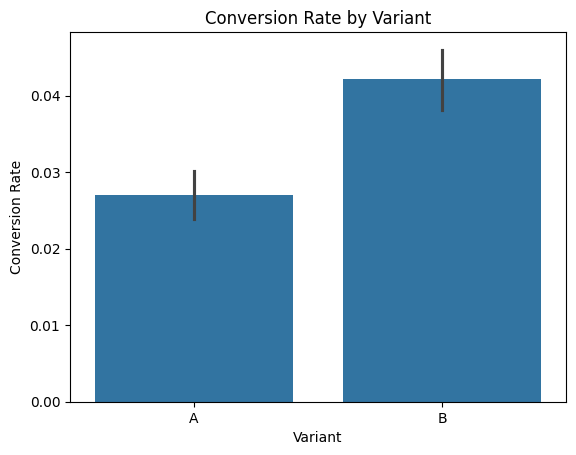

In [8]:
# 1. Coversion Rate Bar plot
sns.barplot(x='Variant', y='Conversions', data=df)
plt.title("Conversion Rate by Variant")
plt.ylabel("Conversion Rate")
plt.xlabel("Variant")
plt.show()

#### It shows The B varient performs well

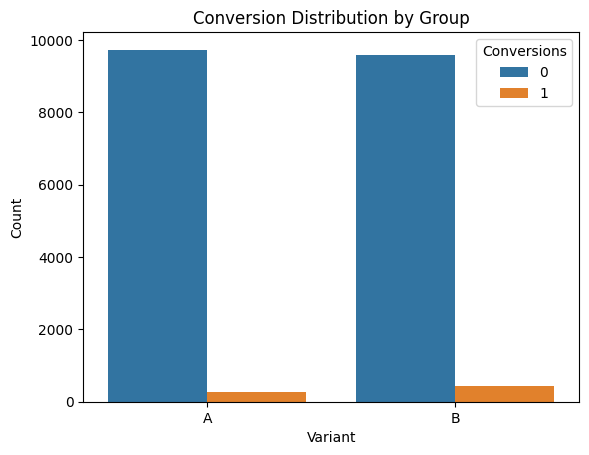

In [9]:
# 2. Count Plot for distribution of conversion
sns.countplot(x='Variant', hue='Conversions', data=df)
plt.title("Conversion Distribution by Group")
plt.xlabel("Variant")
plt.ylabel("Count")
plt.show()

#### Shows How many coverted and not

In [10]:
print(df['Variant'].unique())


['A' 'B']


In [11]:
#3. Conversion Rate Difference
control_rate = df[df['Variant']=='A']['Conversions'].mean()
treatment_rate = df[df['Variant']=='B']['Conversions'].mean()

diff = treatment_rate - control_rate

print("Conversion Difference:", diff)

Conversion Difference: 0.015200000000000002


## 7. Hypothesis Testing
H₀: No difference between groups

H₁: New version is better

## 8. Z-Test

In [12]:
control = df[df['Variant']=='A']['Conversions']
treatment = df[df['Variant']=='B']['Conversions']

In [13]:
n1 = len(control)
n2 = len(treatment)

p1 = control.mean()#Mean of control
p2 = treatment.mean()# treatment Mean

In [14]:
p_pool = (control.sum() + treatment.sum()) / (n1 + n2)
p_pool

0.0346

In [15]:
#Standerad Error se
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
se

0.0025846794772273023

In [16]:
#Find Z score with mean values A,B
z = (p2 - p1) / se
print("Z-score:", z)

Z-score: 5.880806550259648


In [17]:
#Find P valueof One tailed test

from scipy.stats import norm

p_value=1- norm.cdf(z)

print("p_value:",p_value)

p_value: 2.04136052506243e-09


## 9. Confidence Interval for A/B Testing
We will calculate CI for: Control (A),Treatment (B)

In [18]:
control = df[df['Variant']=='A']['Conversions']
treatment = df[df['Variant']=='B']['Conversions']

n1 = len(control)
n2 = len(treatment)

p1 = control.mean()
p2 = treatment.mean()

#For 95% CI  Z = 1.96

#For control Group cI
z = 1.96

se1 = np.sqrt(p1 * (1 - p1) / n1)

lower1 = p1 - z * se1
upper1 = p1 + z * se1

print("Control CI:", (lower1, upper1))

#For Treatment Group CI
se2 = np.sqrt(p2 * (1 - p2) / n2)

lower2 = p2 - z * se2
upper2 = p2 + z * se2

print("Treatment CI:", (lower2, upper2))

Control CI: (0.023823167086546727, 0.030176832913453272)
Treatment CI: (0.03825951468653924, 0.046140485313460766)


###  Confidence intervals show the range in which true conversion rates lie.
1. If the confidence intervals of control and treatment overlap significantly, the difference may not be meaningful.
2. If the CI of the difference does not include 0, the result is statistically significant.

## 10. Decision:


In [19]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0, Treatment is better")
else:
    print("Fail to reject H0, No significant difference")

Reject H0, Treatment is better


## Final Conclusion

- The p-value obtained from the Z-test is extremely small (≈ 2.04e-09), which is far below the significance level of 0.05.
- Therefore, we reject the null hypothesis.
- This indicates that the difference in conversion rates between Variant A (control) and Variant B (treatment) is statistically significant.

## Business Decision

- The treatment group (Variant B) shows a statistically significant improvement in conversion rate compared to the control group (Variant A).
- Hence, the company should adopt the new website design to improve user conversions.

## Final Insight

- The improvement is not due to random chance.
- The result is highly reliable due to the very low p-value.